In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, ScalarFormatter
import seaborn as sns

# Funktion zum Einlesen und Parsen der .log-Datei
def parse_log_file(log_file):
    try:
        # Öffnen und Lesen der .log-Datei
        with open(log_file, 'r') as file:
            lines = file.readlines()

        # Rohdaten separat für Ein/Aus speichern
        raw_data = {
            'Step': [],
            'psw_m1_ein': [], 'psw_m1_aus': [],
            'psw_m2_ein': [], 'psw_m2_aus': [],
            'psw_m3_ein': [], 'psw_m3_aus': [],
            'vds_m1': [], 'vds_m2': [], 'vds_m3': []
        }

        current_measurement = None

        for i, line in enumerate(lines):
            if line.startswith("Measurement:"):
                current_measurement = line.split(":")[1].strip()
                continue

            parts = line.strip().split()
            if not parts or not parts[0].isdigit():
                continue

            step = int(parts[0])
            try:
                value = float(parts[1])
            except:
                continue

            if current_measurement == 'psw_m1_ein':
                raw_data['Step'].append(step)
                raw_data['psw_m1_ein'].append(value)
            elif current_measurement == 'psw_m1_aus':
                raw_data['psw_m1_aus'].append(value)
            elif current_measurement == 'psw_m2_ein':
                raw_data['psw_m2_ein'].append(value)
            elif current_measurement == 'psw_m2_aus':
                raw_data['psw_m2_aus'].append(value)
            elif current_measurement == 'psw_m3_ein':
                raw_data['psw_m3_ein'].append(value)
            elif current_measurement == 'psw_m3_aus':
                raw_data['psw_m3_aus'].append(value)
            elif current_measurement == 'vds_m1':
                raw_data['vds_m1'].append(value)
            elif current_measurement == 'vds_m2':
                raw_data['vds_m2'].append(value)
            elif current_measurement == 'vds_m3':
                raw_data['vds_m3'].append(value)

        # Summieren von Ein + Aus zu Gesamt-Psw pro MOSFET
        psw_m1 = [ein + aus for ein, aus in zip(raw_data['psw_m1_ein'], raw_data['psw_m1_aus'])]
        psw_m2 = [ein + aus for ein, aus in zip(raw_data['psw_m2_ein'], raw_data['psw_m2_aus'])]
        psw_m3 = [ein + aus for ein, aus in zip(raw_data['psw_m3_ein'], raw_data['psw_m3_aus'])]

        # DataFrame erzeugen mit den kombinierten Werten
        df = pd.DataFrame({
            'Step': raw_data['Step'],
            'Psw_M1': psw_m1,
            'Psw_M2': psw_m2,
            'Psw_M3': psw_m3,
            'Vds_M1': raw_data['vds_m1'],
            'Vds_M2': raw_data['vds_m2'],
            'Vds_M3': raw_data['vds_m3'],
        })

        return df

    except FileNotFoundError:
        print(f"Fehler: Die Datei {log_file} wurde nicht gefunden.")
    except Exception as e:
        print(f"Ein unerwarteter Fehler ist aufgetreten: {e}")

# Hauptteil des Programms
log_file = "Messprojekt.log"  # Gib hier den Pfad zur Log-Datei an
df = parse_log_file(log_file)

if df is not None:
    # Zeige das Ergebnis
    print(df)

    # Optional: Speichere das Ergebnis als CSV-Datei
    df.to_csv('Messdaten.csv', index=False)


     Step    Psw_M1    Psw_M2    Psw_M3  Vds_M1  Vds_M2  Vds_M3
0       1  0.000121  0.001198  0.000266     5.0     5.0     5.0
1       2  0.001108  0.001198  0.000266    15.0     5.0     5.0
2       3  0.003143  0.001198  0.000266    25.0     5.0     5.0
3       4  0.006597  0.001198  0.000266    35.0     5.0     5.0
4       5  0.009342  0.001198  0.000266    40.0     5.0     5.0
..    ...       ...       ...       ...     ...     ...     ...
120   121  0.000037  0.076827  0.017036     5.0    40.0    40.0
121   122  0.000395  0.076835  0.017036    15.0    40.0    40.0
122   123  0.001100  0.076836  0.017036    25.0    40.0    40.0
123   124  0.002184  0.076831  0.017036    35.0    40.0    40.0
124   125  0.002431  0.076840  0.017036    40.0    40.0    40.0

[125 rows x 7 columns]


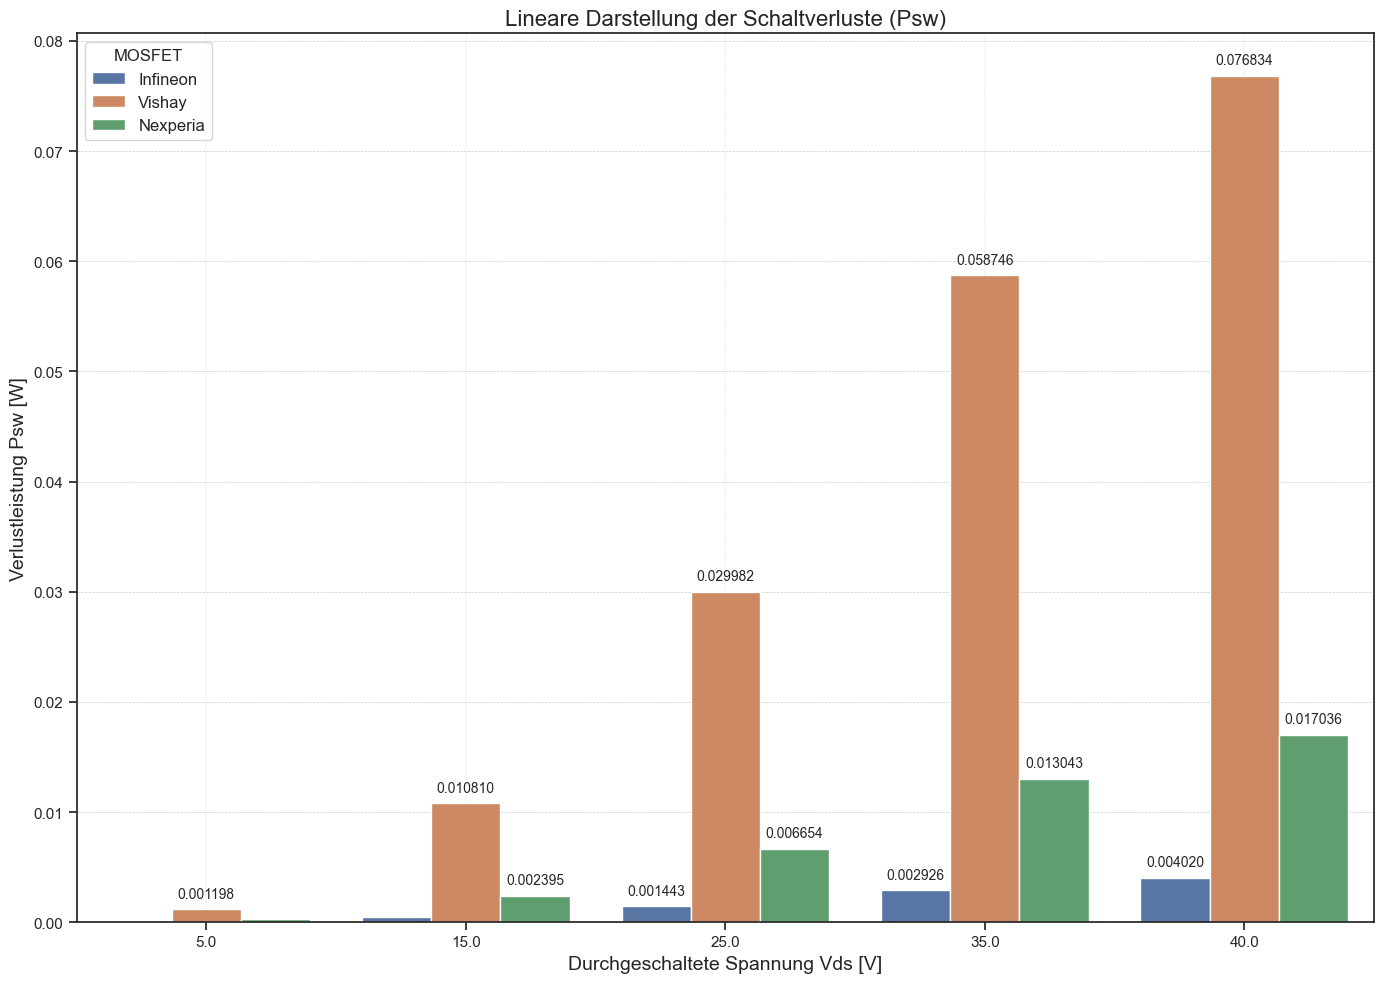

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CSV laden
df = pd.read_csv('Messdaten.csv')

# MOSFET-Namen zuweisen
mosfet_labels = ['Infineon'] * len(df) + ['Vishay'] * len(df) + ['Nexperia'] * len(df)

# Daten umformen für barplot
psw_data = pd.DataFrame({
    'MOSFET': mosfet_labels,
    'Vds': df['Vds_M1'].tolist() + df['Vds_M2'].tolist() + df['Vds_M3'].tolist(),
    'Psw': df['Psw_M1'].tolist() + df['Psw_M2'].tolist() + df['Psw_M3'].tolist()
})

# Vds runden für saubere Gruppierung
psw_data['Vds'] = psw_data['Vds'].round(0)

# Kleine Werte optional filtern (z. B. < 0.01 W nicht anzeigen)
# psw_data = psw_data[psw_data['Psw'] >= 0.01]

# Stil
sns.set(style="ticks")

# Plot erzeugen
plt.figure(figsize=(14, 10))
ax = sns.barplot(
    data=psw_data,
    x='Vds',
    y='Psw',
    hue='MOSFET',
    errorbar=None  # <- verhindert den "Strich" (Standardfehler)
)

# Y-Achse linear
ax.set_yscale('linear')

# Gitterlinien
ax.grid(True, which='both', axis='y', linestyle='--', linewidth=0.5)
ax.grid(True, which='major', axis='x', linestyle='--', linewidth=0.3)

# Balkenwerte annotieren
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0.001:  # Beschriftung nur bei sinnvollen Werten
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + max(psw_data['Psw']) * 0.01,
                f"{height:.6f}",
                ha='center',
                va='bottom',
                fontsize=10
            )

# Achsentitel und Legende
plt.title('Lineare Darstellung der Schaltverluste (Psw)', fontsize=16)
plt.xlabel('Durchgeschaltete Spannung Vds [V]', fontsize=14)
plt.ylabel('Verlustleistung Psw [W]', fontsize=14)
plt.legend(title='MOSFET', fontsize=12, title_fontsize=12)

plt.tight_layout()
plt.show()
